### Importações

In [1]:
!pip install pandas

In [2]:
!pip install scipy

In [3]:
!pip install seaborn

In [4]:
!pip install scikit-learn

In [5]:
!pip install huggingface_hub

In [6]:
!pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [7]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e .

fatal: destination path 'sam3' already exists and is not an empty directory.
/workspace/sam3
Obtaining file:///workspace/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
  Created wheel for sam3: filename=sam3-0.1.0-0.editable-py3-none-any.whl size=15195 sha256=12ec2e0f9a9abee8464e45bde9736d027bfce0e42fa201297371ccd5d841d18f
  Stored in directory: /tmp/pip-ephem-wheel-cache-6asf4pby/wheels/44/c8/35/e69d8837c5b23771f3a6f3af6db820f879a38fa2485d3622e9
Successfully built sam3
  Attempting uninstall: sam3
    Found existing installation: sam3 0.1.0
    Uninstalling sam3-0.1.0:
      Successfully uninstalled sam3-0.1.0


In [8]:
!pip install einops

In [9]:
!pip install decord

In [10]:
!pip install pycocotools

In [11]:
import os
print(os.getcwd())

/workspace/sam3


In [12]:
import os
import numpy as np
import pandas as pd

from PIL import Image

import torch
from scipy.ndimage import binary_opening, binary_closing

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

# Progress bar
try:
    from tqdm.notebook import tqdm  # Jupyter
except ImportError:
    from tqdm import tqdm

# SAM3
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

## SAM3

In [13]:
model = build_sam3_image_model()
processor = Sam3Processor(model)
model.eval()

Sam3Image(
  (backbone): SAM3VLBackbone(
    (vision_backbone): Sam3DualViTDetNeck(
      (trunk): ViT(
        (patch_embed): PatchEmbed(
          (proj): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
        )
        (blocks): ModuleList(
          (0): Block(
            (norm1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (attn): Attention(
              (qkv): Linear(in_features=1024, out_features=3072, bias=True)
              (proj): Linear(in_features=1024, out_features=1024, bias=True)
            )
            (ls1): Identity()
            (drop_path): Identity()
            (norm2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=1024, out_features=4736, bias=True)
              (act): GELU(approximate='none')
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=4736, out_features=1024, b

## Prompts

In [14]:
SAM3_PROMPTS = {
    "face":     "face",        
    "nose":     "nose",          
    "mouth":    "mouth",         
    "l_eye":    "left eye",      
    "r_eye":    "right eye",     
    "hair":     "hair"           
}


## Função de segmentação

In [15]:
def sam3_segment_parts(img_rgb, score_threshold: float = 0.7):
    w, h = img_rgb.size
    inference_state = processor.set_image(img_rgb)
    part_masks = {}

    for part_name, prompt in SAM3_PROMPTS.items():
        output = processor.set_text_prompt(state=inference_state, prompt=prompt)
        masks = output["masks"]
        scores = output["scores"]

        if masks is None or masks.shape[0] == 0:
            part_masks[part_name] = np.zeros((h, w), dtype=bool)
            continue

        best_idx = torch.argmax(scores).item()
        if scores[best_idx].item() < score_threshold:
            part_masks[part_name] = np.zeros((h, w), dtype=bool)
            continue

        m = masks[best_idx]
        if m.ndim == 3: m = m[0]
        if m.dtype != torch.bool: m = m > 0.5
        part_masks[part_name] = m.detach().cpu().numpy().astype(bool)

    return part_masks

def clean_mask(mask: np.ndarray) -> np.ndarray:
    opened = binary_opening(mask, structure=np.ones((3, 3)))
    return binary_closing(opened, structure=np.ones((3, 3)))


## SHPM

In [16]:
def extract_shpm_vector(input_path: str, show_progress: bool = False) -> pd.DataFrame:
    if os.path.isdir(input_path):
        image_paths = [os.path.join(input_path, f) for f in os.listdir(input_path) 
                       if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))]
    else:
        image_paths = [input_path]

    rows = []
    idx_list = []
    

    parts_list = list(SAM3_PROMPTS.keys())

    feature_names = []
    for i in range(len(parts_list)):
        for j in range(len(parts_list)):
            if i != j:
                feature_names.append(f"{parts_list[i]}_vs_{parts_list[j]}")

    it = tqdm(image_paths, desc=f"Proc. {os.path.basename(input_path.rstrip('/'))}") if show_progress else image_paths

    for img_path in it:
        try:
            img_rgb = Image.open(img_path).convert("RGB")
            
            raw_masks = sam3_segment_parts(img_rgb)
            masks = {k: clean_mask(v) for k, v in raw_masks.items()}
            
         
            areas = {}
            for part, mask in masks.items():
                areas[part] = np.sum(mask)

            if areas.get("face", 0) < 100: continue

            # [cite_start]Proportion Vector [cite: 70]
            current_vector = []
            for i in range(len(parts_list)):
                for j in range(len(parts_list)):
                    if i != j:
                        p1, p2 = parts_list[i], parts_list[j]
                        area1 = areas.get(p1, 0)
                        area2 = areas.get(p2, 0)
       
                        ratio = (area1 / area2) if area2 > 0 else 0.0
                        current_vector.append(ratio)

            rows.append(current_vector)
            idx_list.append(os.path.basename(img_path))
            
        except Exception:
            continue

    if not rows: return pd.DataFrame(columns=feature_names)
    return pd.DataFrame(rows, columns=feature_names, index=idx_list)

## Cálculo do SHPM

In [17]:
folders = {
    "Pele":      "Pelé/",
    "Serena":    "Serena Williams/",
    "Jackie":    "Jackie Chan/",
    "Han Kang":  "Han Kang/",
    "Senna":     "Ayrton Senna/",
    "Marie":     "Marie Curie/",
}

# 1. Extraction
raw_dfs = {}
for name, folder in folders.items():
    if os.path.exists(folder):
        df = extract_shpm_vector(folder, show_progress=True)
        raw_dfs[name] = df.fillna(0.0)
    else:
        raw_dfs[name] = pd.DataFrame()


valid_dfs = [df for df in raw_dfs.values() if not df.empty]
if not valid_dfs: raise ValueError("No data.")

all_data = pd.concat(valid_dfs, axis=0)

Proc. Pelé:   0%|          | 0/10 [00:00<?, ?it/s]

Proc. Serena Williams:   0%|          | 0/10 [00:00<?, ?it/s]

Proc. Jackie Chan:   0%|          | 0/10 [00:00<?, ?it/s]

Proc. Han Kang:   0%|          | 0/10 [00:00<?, ?it/s]

Proc. Ayrton Senna:   0%|          | 0/10 [00:00<?, ?it/s]

Proc. Marie Curie:   0%|          | 0/10 [00:00<?, ?it/s]

In [18]:
scaler = MinMaxScaler() 
scaler.fit(all_data) 

norm_dfs = {}
for name, df in raw_dfs.items():
    if not df.empty:
        arr_scaled = scaler.transform(df)
        norm_dfs[name] = pd.DataFrame(arr_scaled, columns=df.columns, index=df.index)
    else:
        norm_dfs[name] = df

## Fidelidade

In [27]:
def cosine_similarity(u, v):

    norm_u = np.linalg.norm(u)

    norm_v = np.linalg.norm(v)

    if norm_u == 0 or norm_v == 0: return 0.0

    return np.dot(u, v) / (norm_u * norm_v)

def sigmoid_adjustment(score, mu, beta):

    """
    Eq: S_adj = 1 / (1 + e^(-beta * (F - mu))) 

    """

    return 1.0 / (1.0 + np.exp(-beta * (score - mu)))

def calculate_cross_fidelity(df1, df2):
    if df1.empty or df2.empty: return 0.0
    
    scores = []
    # Full Loop (Cartesian Product)
    for _, row1 in df1.iterrows():
        for _, row2 in df2.iterrows():
            sim = cosine_similarity(row1, row2)
            scores.append(sim)
            
    if not scores: return 0.0
    avg_fidelity = np.mean(scores)
    return sigmoid_adjustment(avg_fidelity, mu=0.88, beta=10)

def calculate_internal_fidelity(df):
    if len(df) < 2: return 1.0 
    
    scores = []
    for i in range(len(df)):
        for j in range(i + 1, len(df)):
            row1 = df.iloc[i]
            row2 = df.iloc[j]
            sim = cosine_similarity(row1, row2)
            scores.append(sim)
            
    if not scores: return 1.0
    avg_fidelity = np.mean(scores)
    return sigmoid_adjustment(avg_fidelity, mu=0.88, beta=10)

## Heatmap

SHPM Matrix
              Pele    Serena    Jackie  Han Kang     Senna     Marie
Pele      1.000000  0.100071  0.167603  0.177558  0.141333  0.158920
Serena    0.214813  1.000000  0.153427  0.386410  0.237408  0.097107
Jackie    0.362292  0.154499  1.000000  0.176578  0.532108  0.072123
Han Kang  0.311946  0.316254  0.143515  1.000000  0.083376  0.163834
Senna     0.262940  0.205758  0.457969  0.088291  1.000000  0.042385
Marie     0.448319  0.127617  0.094125  0.263071  0.064269  1.000000


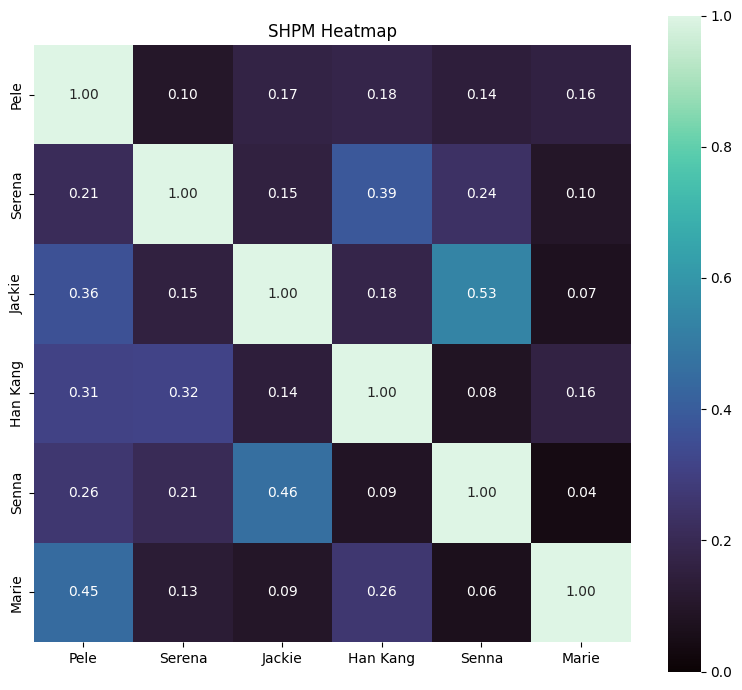

In [28]:
names = list(norm_dfs.keys())
n = len(names)
fidelity_mat = np.zeros((n, n))

# Main comparison loop
for i, name_i in enumerate(names):
    for j, name_j in enumerate(names):
        df_i = norm_dfs[name_i]
        df_j = norm_dfs[name_j]
        
        if df_i.empty or df_j.empty:
            fidelity_mat[i, j] = 0.0
            continue
            
        if i == j:
            fidelity_mat[i, j] = calculate_internal_fidelity(df_i)
        else:
            fidelity_mat[i, j] = calculate_cross_fidelity(df_i, df_j)

fidelity_df = pd.DataFrame(fidelity_mat, index=names, columns=names)




print("SHPM Matrix")
print(fidelity_df)

plt.figure(figsize=(8, 7))
sns.heatmap(
    fidelity_df, 
    annot=True, 
    fmt=".2f", 
    cmap="mako", 
    vmin=0.0, 
    vmax=1.0,
    square=True
)
plt.title("SHPM Heatmap")
plt.tight_layout()
plt.show()